In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split  # 用于将数据集分割为训练集和测试集
from sklearn.preprocessing import StandardScaler  # 数据标准化工具，将特征缩放到相同尺度
from sklearn.linear_model import LinearRegression  # 线性回归模型，用于建立预测模型
from sklearn.metrics import mean_squared_error, r2_score # 模型评估指标，衡量预测性能
data = pd.read_csv("D:\\Project\\AI_learning\\housing.csv")
#分离特征（输入）和目标变量（输出）
X = data.drop('median_house_value', axis=1) # 创建特征矩阵 X（输入变量）
y = data['median_house_value'] # 创建目标向量 y（输出变量）
# 处理分类特征
if 'ocean_proximity' in X.columns:
    X = pd.get_dummies(X, columns=['ocean_proximity']) # get_dummies把文字转成数字：每个选项变成一列，有就是1，没有就是0
# 填充缺失值
X = X.fillna(X.median()) # fillna用中位数填上空值
# 划分数据集：把数据分成训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 数据标准化：把数据调到同一个尺度
scaler = StandardScaler()
# fit：计算训练集的平均值和标准差
# transform：用计算出的值转换训练集
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# 训练模型
model = LinearRegression()
model.fit(X_train, y_train)
# 预测和评估
y_pred = model.predict(X_test)
print("均方误差:", round(mean_squared_error(y_test, y_pred), 2))
print("R²分数:", round(r2_score(y_test, y_pred), 4))

均方误差: 4908476721.16
R²分数: 0.6254


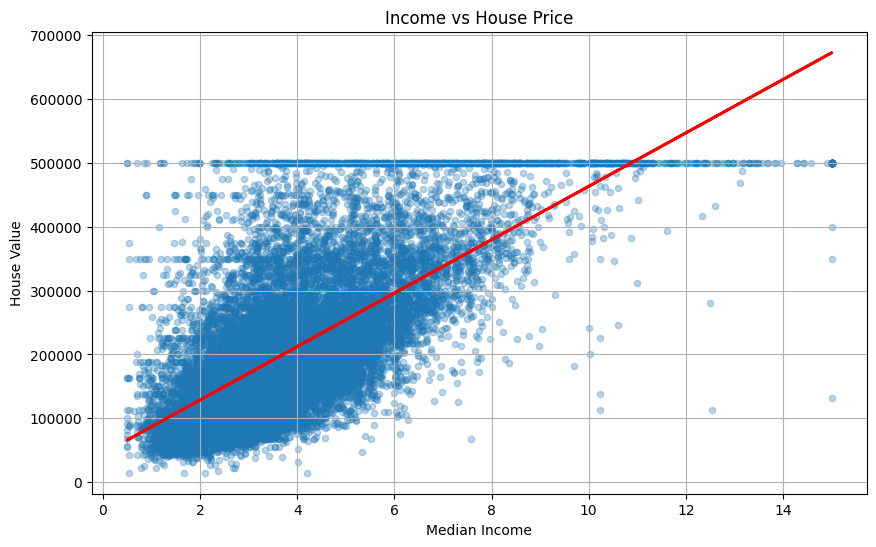

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
# 收入与房价散点图
plt.figure(figsize=(10, 6))
plt.scatter(data['median_income'], data['median_house_value'], alpha=0.3, s=20)
# 计算回归线
x = data['median_income']
y = data['median_house_value']
coef = np.polyfit(x, y, 1)
reg_line = np.poly1d(coef)
plt.plot(x, reg_line(x), 'r-', linewidth=2)
plt.title('Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.grid(True)
plt.show()